In [1]:
import utils
print(f"utils : {utils.__version__}")
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device, find_nearest_atoms
from utils.plots import plot_with_center # plotting
from utils.energies import hamiltonian, multi_LDOS_parallel, multi_LDOS
from utils import pretty_print_columns


import sisl
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
from tqdm.notebook import tqdm

import ipywidgets
from ipywidgets import interact
from fractions import Fraction


%reload_ext line_profiler


utils : 0.2.2


# Global parameters

In [2]:
ENERGIES = np.linspace(-2, 2, num=50)

# Benchmark full device: flake convergence
This is how I expect the final structure to converge when computing the LDOS from self-energies

In [3]:
def make_benchmark(size, energies):
    """Built graphene flake for benchmarking"""
    flake = sisl.geom.graphene_flake(size)
    H = hamiltonian(flake)
    es = H.eigenstate()
    pdos = es.PDOS(E=energies).squeeze() # reduce from (1, N, M) -> (N, M)
    center_pdos = pdos[0]
    return center_pdos

loop:   0%|          | 0/4 [00:00<?, ?it/s]

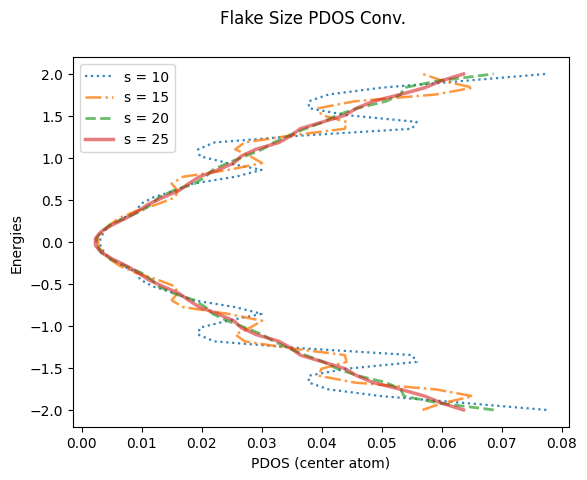

In [4]:
sizes = [10, 15, 20, 25]
fig, axes = plt.subplots()
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
LINESTYLE = [":", "-.", "--", "-"]
ALPHA = [0.9, 0.8, 0.7, 0.6]
LINEWIDTH = [2.5, 2.0, 1.8, 1.6][::-1]
for i, s in enumerate(tqdm(sizes, desc="loop")):
    pdos = make_benchmark(s, ENERGIES)
    axes.plot(pdos, ENERGIES, label=f"{s = }",
              alpha=ALPHA[i], color=COLORS[i],
              linestyle=LINESTYLE[i], lw=LINEWIDTH[i])

axes.set_xlabel("PDOS (center atom)")
axes.set_ylabel("Energies")
axes.legend()
fig.suptitle(f"Flake Size PDOS Conv.")
fig.savefig("figures/graphene_flake_PDOS_convergence.png")


# Benchmark Electrode: self-energy method against built-in

In [5]:
def mark_electrode(lr_indices):
    """Helper function for plotting electrodes.
    Colors 'left' and 'right' electrodes using blue and red respectively.
    Scales the atom sizes to match opposing electrodes."""
    atoms_style = []
    for i, (l, r) in enumerate(zip(*lr_indices)):
        atoms_style += [{"atoms": l, "size": i*0.3 + 0.5, "color": "blue"}]
        atoms_style += [{"atoms": r, "size": i*0.3 + 0.5, "color": "red"}]
    return atoms_style

In [6]:
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    bz = sisl.MonkhorstPack(ham, [nk, 1, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies))
    return dos, bs, (lk, kticks, knames)

In [7]:
width = 20
length = 2
center_size = 2
__params__ = f"{width}W_{length}L_{center_size}C"
electrode = build_electrode(width=width, length=length)
ribbon = build_nanoribbon(electrode=electrode, center_size=center_size)
device_ribbon, lr_idx_ribbon = build_reduced_device(ribbon, electrode, repeat=1)
device_ribbon.write(f"structures/ribbon_{__params__}.xyz")
atoms_style = mark_electrode(lr_idx_ribbon)

plot_with_center(device_ribbon, atoms_style=atoms_style)

       Initial number of atoms: 320
 Atoms after removing overlaps: 320


In [8]:
def plot_dos_band(device, nk, energies):
    """Plot the device band structure and DOS"""
    H = hamiltonian(device)
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    fig.suptitle(f"Built-in calc L={length}, W={width}, C={center_size}")
    axes[0].set_title("Band structure")    
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].set_title("DOS")
    axes[1].plot(dos, energies)
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    fig.tight_layout()
    for ax in axes:
        ax.grid()
    
    return fig, axes

## Built-in calculations for bands and DOS

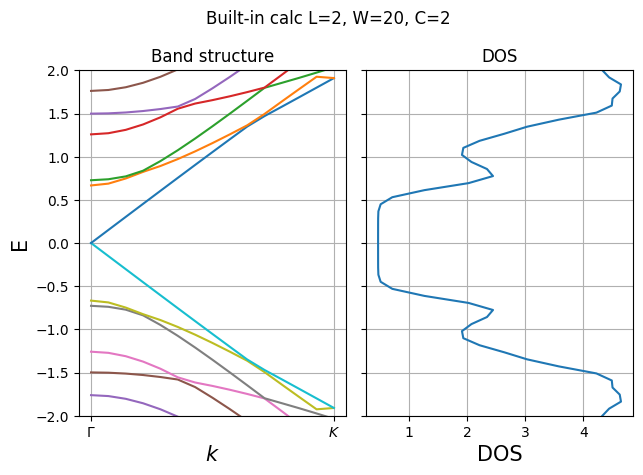

In [9]:
fig, axes = plot_dos_band(electrode, 100, ENERGIES)
minmax = 2
axes[0].set(ylim=(-minmax, minmax))
fig.savefig(f"figures/electrode_bands_DOS_{__params__}.png")

## Self-energy LDOS VS. built-in DOS 

In [10]:
Nk = 1
all_ldos = multi_LDOS(device=device_ribbon, 
                     electrode=electrode, 
                     lr_indices=lr_idx_ribbon, 
                     energies=ENERGIES, Nk=Nk, eta=1e-5, form="csc")


k-points:   0%|          | 0/1 [00:00<?, ?it/s]

Energy:   0%|          | 0/50 [00:00<?, ?it/s]

In [13]:
dos, bs, lk = electrode_dos(hamiltonian(device_ribbon), 100, ENERGIES)

In [14]:
np.savez(f"calculations/ldos_{__params__}", energies=ENERGIES, 
         ldos=all_ldos, dos=dos, bs=bs, ks=lk[0], ls=lk[1])

In [15]:
def plot_ldos(kidx, site, fixed_scale, samefig=True):
    """Plot LDOS from self-energy calculation with DOS from built-ins"""
    
    X1 = all_ldos[kidx, :, site]
    X2 = dos
    
    # only used if fixed_scale=True
    ymin, ymax = np.min([np.min(all_ldos), np.min(dos)]), np.max([np.max(all_ldos), np.max(dos)])
    
    if samefig: # plot in the save figure
        fig, axes = plt.subplots(1,1)
    
        normalize = lambda arr: (arr - arr.mean()) / arr.std()
        X1 = normalize(X1)
        X2 = normalize(X2)
        axes.plot(X1, ENERGIES, label="SE (LDOS)")
        axes.plot(X2, ENERGIES, label="Built-in (DOS)")
        axes.set_xlabel("DOS (normalized)")
        axes.legend()
        axes.set_ylabel("E")
        axes.set_title("DOS for nanoribbon")
        if fixed_scale:
            # ymin, ymax = np.min([np.min(all_ldos), np.min(dos)]), np.max([np.max(all_ldos), np.max(dos)])
            axes.set_xlim(-ymax*0.1, ymax*1.01)
    
    else: # plot as subfigure
        fig, axes = plt.subplots(1,2, sharey=True)
        axes[0].plot(X1, ENERGIES)
        axes[0].set_title("SE (LDOS)")
        axes[0].set_ylabel("Energies")
        
        axes[1].plot(X2, ENERGIES)
        axes[1].set_title("Built-in (DOS)")
        
        for ax in axes:
            ax.set_xlabel("DOS")
            if fixed_scale:
                ax.set_xlim(-ymax*0.1, ymax*1.01)
    
    fig.suptitle(f"L={length}, W={width}, C={center_size}")

DEVICE_CENTER_ATOMS = find_nearest_atoms(device_ribbon.xyz, device_ribbon.center(), neighbours=6)
print(DEVICE_CENTER_ATOMS)

kpts = sisl.MonkhorstPack(hamiltonian(device_ribbon), [Nk, 1, 1])
options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
ks = ipywidgets.Dropdown(options=options, description="k")
static = ipywidgets.fixed(all_ldos)
# sites = ipywidgets.IntSlider(min=left_idx[0].max()+1, max=right_idx[0].min()-1, value=left_idx[0].min(), description="Site")
sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")

scale = ipywidgets.Checkbox(value=False, description="Use fixed scale", indent=True)
same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
interact(plot_ldos, kidx=ks, site=sites, fixed_scale=scale, samefig=same)

[155 165 144 174 154 164]


interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(kidx, site, fixed_scale, samefig=True)>